Introduction
========

This tutorial requires simbench and RLLib, which is not included in the pandapower_env package.

Imports
=========

In [16]:
import pandapower as pp
from pandapower.networks import case2869pegase, case118, case14, case30
import pandapower.plotting as plot

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import copy

import simbench

In [17]:
from pandapower_env.substation.create_double_busbar_substation import (
    create_all_double_busbar_substations,
    create_double_busbar_substation,
)

from pandapower_env.substation.plot_double_busbar_substation import (
    create_double_busbar_plotting_net,
    separate_substation_buses_visually,
)

from pandapower_env.toolbox.plotting_helpers import (
    calculate_externals_locations,
    create_bus2bus_geodata,
    plot_all_peripherals,
    label_lines,
    label_buses,
    label_substations,
)
from pandapower_env.data.example_configs import config_case30

from pandapower_env.environments.gym_env_pp import BaseEnvPP

Load the network
=========

Create the double-busbar substation 
==========

In [18]:
config = config_case30()
net = config["net"]
actions = config["action_space"]
print(actions[265])

print(net.line)


defaultdict(<class 'list'>, {'action': 265, 'lines': [0], 'disconnect_lines': [True]})
    name std_type  from_bus  to_bus  length_km  r_ohm_per_km  x_ohm_per_km  \
0   None     None         0      31        1.0        3.6450       10.9350   
1   None     None         0       2        1.0        9.1125       34.6275   
2   None     None        32      38        1.0       10.9350       30.9825   
3   None     None         2      39        1.0        1.8225        7.2900   
4   None     None        33       4        1.0        9.1125       36.4500   
5   None     None        34      44        1.0       10.9350       32.8050   
6   None     None        40      45        1.0        1.8225        7.2900   
7   None     None         4       6        1.0        9.1125       21.8700   
8   None     None        46       6        1.0        5.4675       14.5800   
9   None     None        47       7        1.0        1.8225        7.2900   
10  None     None        48       8        1.0        0

In [19]:
net.multi_bb_substation

,bus_0,bus_1,b01_switch,connected_buses,n_busbars_in_substation,element_type,connected_elements,b0_switches,b1_switches
0,1,30,0,"[31, 32, 33, 34, 35, 36]",2,"[line, line, line, line, load, gen]","[0, 2, 4, 5, 0, 0]","[1, 3, 5, 7, 9, 11]","[2, 4, 6, 8, 10, 12]"
1,3,37,13,"[38, 39, 40, 41, 42]",2,"[line, line, line, line, load]","[2, 3, 6, 14, 2]","[14, 16, 18, 20, 22]","[15, 17, 19, 21, 23]"
2,5,43,24,"[44, 45, 46, 47, 48, 49, 50]",2,"[line, line, line, line, line, line, line]","[5, 6, 8, 9, 10, 11, 40]","[25, 27, 29, 31, 33, 35, 37]","[26, 28, 30, 32, 34, 36, 38]"
3,9,51,39,"[52, 53, 54, 55, 56, 57, 58]",2,"[line, line, line, line, line, line, load]","[11, 13, 24, 25, 26, 27, 5]","[40, 42, 44, 46, 48, 50, 52]","[41, 43, 45, 47, 49, 51, 53]"
4,11,59,54,"[60, 61, 62, 63, 64, 65]",2,"[line, line, line, line, line, load]","[14, 15, 16, 17, 18, 6]","[55, 57, 59, 61, 63, 65]","[56, 58, 60, 62, 64, 66]"
5,14,66,67,"[67, 68, 69, 70, 71]",2,"[line, line, line, line, load]","[17, 19, 21, 29, 8]","[68, 70, 72, 74, 76]","[69, 71, 73, 75, 77]"
6,21,72,78,"[73, 74, 75, 76]",2,"[line, line, line, gen]","[27, 28, 30, 1]","[79, 81, 83, 85]","[80, 82, 84, 86]"
7,22,77,87,"[78, 79, 80, 81]",2,"[line, line, load, gen]","[29, 31, 15, 3]","[88, 90, 92, 94]","[89, 91, 93, 95]"
8,23,82,96,"[83, 84, 85, 86]",2,"[line, line, line, load]","[30, 31, 32, 16]","[97, 99, 101, 103]","[98, 100, 102, 104]"
9,26,87,105,"[88, 89, 90, 91, 92]",2,"[line, line, line, line, gen]","[34, 35, 36, 37, 2]","[106, 108, 110, 112, 114]","[107, 109, 111, 113, 115]"


In [20]:
df_actions = pd.DataFrame(dict_actions)
df_actions['states_binary_str'] = df_actions['states'].apply(lambda x: [format(a,'b') for a in x])
df_actions.index.name = None

Plot action
==============

AttributeError: 'int' object has no attribute 'removeprefix'

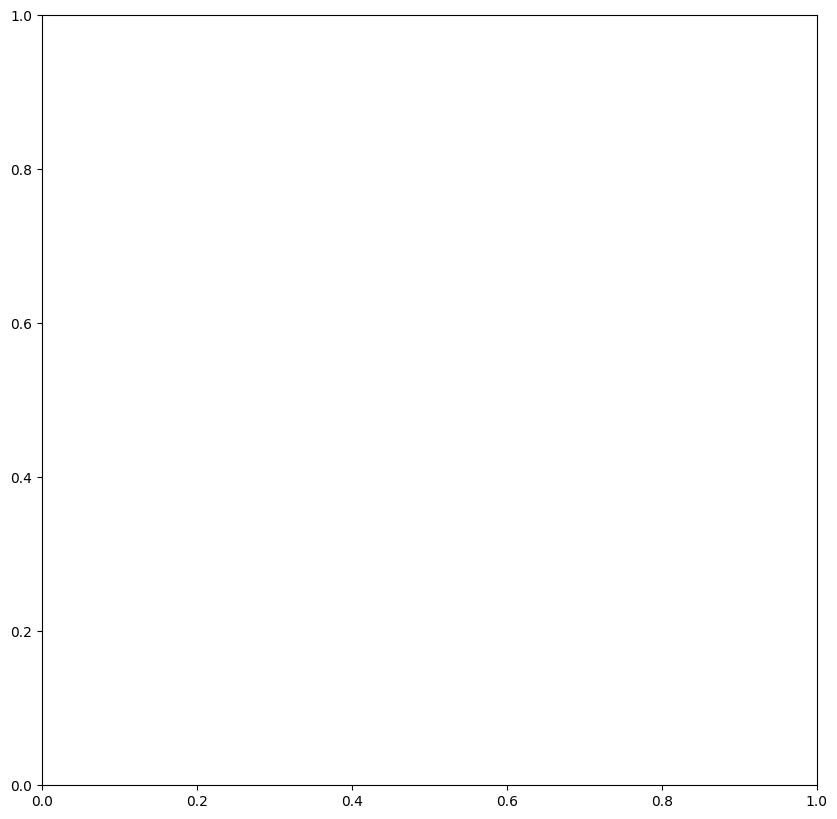

In [21]:
fig,ax = plt.subplots(1,1,figsize=(10,10))

bus_size = 5

bus_geodata = separate_substation_buses_visually(net,df_actions.loc[1],r_split_bus=20)

all_collections = []
line_c = plot.create_line_collection(net, net.line[net.line['vn_kv'] >= vthresh].index, color="silver",zorder=2,linewidths=1,bus_geodata=bus_geodata)
bus_c = plot.create_bus_collection(net, net.bus[net.bus['vn_kv'] >= vthresh].index, color='lightsteelblue',size=bus_size, zorder=3,bus_geodata=bus_geodata)
sub_c = plot.create_bus_collection(net, net.dbb_substation[['bus_0','bus_1']].values.flatten().tolist(), color='darksalmon',size=bus_size*2.0, zorder=4,bus_geodata=bus_geodata)
trafo_c = plot.create_trafo_collection(net, net.trafo[net.trafo['vn_lv_kv'] >= vthresh].index,color="dimgray", size=bus_size*2, linewidths=1,bus_geodata=bus_geodata)
ext_c = plot.create_bus_collection(net,net.ext_grid.index,patch_type="rect",size=bus_size*2.,color='y', zorder=2,bus_geodata=bus_geodata)

for c in [line_c,bus_c,sub_c,trafo_c,ext_c]:
    if c != None :
        all_collections.append(c)

plot_all_peripherals(net,ax,bus_geodata=bus_geodata)
plot.draw_collections(all_collections,ax=ax,axes_visible=(True,True));

label_substations(net,ax,bus_geodata=bus_geodata, labels=['sub {}'.format(i_sub) for i_sub in net.dbb_substation.index])

Grab some timeseries profiles from Simbench
=========

We need some timeseries profiles. Here is some quick code to grab those profiles (do not want to belabor the point here).

We create a `net.profiles` Dataframe to emulate the structure of the simbench grid.

In [54]:
net.profiles = simbench.get_all_simbench_profiles(0)

In [55]:
def get_profile_names(df_profile):
    """
    Quick function to get the names of each of the profiles offered by Simbench
    """
    return df_profile.columns[1:].to_series().apply(lambda x: x.replace('_pload','').replace('_qload','')).unique()

In [56]:
# Randomly select some profiles to load.
rng = np.random.default_rng(seed=12345)
net.load['profile'] = rng.choice(get_profile_names(net.profiles['load']),len(net.load))
net.gen['profile'] = rng.choice(get_profile_names(net.profiles['powerplants']),len(net.gen))

In [57]:
# Make sure loads, generators each have unique names
net.gen['name'] = net.gen.index.to_series().apply(lambda x: f'Generator {x}')
net.sgen['name'] = net.sgen.index.to_series().apply(lambda x: f'Static Generator {x}')
net.load['name'] = net.load.index.to_series().apply(lambda x: f'Load {x}')

In [58]:
net.res_bus

,vm_pu,va_degree,p_mw,q_mvar


Train an agent using RLLib
======

### Create action space

In [59]:
from pandapower_env.action_space.substation_action_rules import (
    passes_two_bus_symmetry_rule,
    passes_islanded_elements_rule,
    passes_n_elements_rule,
    passes_fully_connected_grid_rule,
)
from pandapower_env.substation.substation_bitsets import (
    bitstr,
)
dict_actions = [
    {
        "action": 0,
        "substations": [],
        "substations_str": "do_nothing",
        "n_bits": [],
        "states": [],
        "states_str": "",
        "symmetry": True,
        "nelements": True,
        "island": True,
        "fully_connected": True,
    }
]

n_action = 0
for i_sub, sub in net.dbb_substation.iterrows():
    n_bits = len(sub.connected_elements)

    for state in range(pow(2, n_bits)):
        n_action += 1

        # Impose the rules successively (all previous rules must also be passed)
        pass_symmetry = passes_two_bus_symmetry_rule(sub, state)
        pass_nelements = pass_symmetry and passes_n_elements_rule(sub, state)
        pass_islanding = pass_nelements and passes_islanded_elements_rule(sub, state)
        pass_fully_connected = pass_islanding and passes_fully_connected_grid_rule(
            net, [i_sub], [state]
        )

        dict_actions.append(
            {
                "action": n_action,
                "substations": [i_sub],
                "substations_str": str(i_sub),
                "n_bits": [n_bits],
                "states": [state],
                "states_str": [bitstr(state, n_bits)],
                "symmetry": pass_symmetry,
                "nelements": pass_nelements,
                "island": pass_islanding,
                "fully_connected": pass_fully_connected,
            }
        )
len(dict_actions)

289

In [60]:
from pandapower_env.environments.simulation_env import PPTopoGym
my_config = {
    "net": net,             # Ensure 'net' is defined
    "n_episodes": 10,
    "episode_length": 10,
    "action_space": dict_actions,  # Ensure 'dict_actions' is defined
}
# Create an instance of your environment.
env = PPTopoGym(my_config)

obs = env.create_observation()
obs, _ ,_, _, _ =env.step(1)
obs

{'adjacency_matrix': array([[0, 0],
        [0, 0],
        [0, 0],
        [0, 0],
        [0, 0],
        [0, 0],
        [0, 0],
        [0, 0],
        [0, 0],
        [0, 0],
        [0, 0],
        [0, 0],
        [0, 0],
        [0, 0],
        [0, 0],
        [0, 0],
        [0, 0],
        [0, 0],
        [0, 0],
        [0, 0]], dtype=int32),
 'bus_generators': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0.], dtype=float32),
 'bus_loads': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0.], dtype=float32),
 'bus_voltage_angle': array([0., 0., 0., 0., 0., 0., 0., 0.,

In [61]:
from pandapower_env.environments.simulation_env import PPTopoGym
import os
import ray
from pandapower_env.rlib_agents.gnn_agents import GINETorchRLModule
from pandapower_env.rlib_agents.callbacks import RayCallbacks
from ray.rllib.algorithms.ppo import PPOConfig
from ray.tune.registry import register_env
from ray.rllib.core.rl_module.rl_module import RLModuleSpec
from ray.util.annotations import RayDeprecationWarning
import warnings
from gymnasium import spaces

os.environ["PYTHONWARNINGS"] = "ignore::DeprecationWarning"
warnings.filterwarnings("ignore", category=RayDeprecationWarning)

#print( # check required apis
#    PPOConfig()
#    .get_default_learner_class()
#    .rl_module_required_apis()
#)
def env_creator(env_config):
    return PPTopoGym(env_config)
register_env("SimulationEnvV0", env_creator) # register env with env creator function

my_config = {
    "net": net, # ensure net is defined
    "n_episodes": 100,
    "episode_length": 100,
    "action_space": dict_actions,  # ensure dict_actions is defined
}

# You need to create an instance of your environment to get observation_space & action_space
env = PPTopoGym(my_config)

# create config for the agent
model_cfg = { 
    "gine_hidden_dims":     [512, 512, 512],   # each entry is one GINEConv
    "gine_mlp_layers":      3,                 
    "gine_mlp_activation":  "relu",            # relu | elu 

    "pooling":              "mean",            # mean | max | add

    "fc_hidden_dims":       [512, 512],
    "fc_activation":        "relu",            # relu | elu 
}
action_space = spaces.Discrete(len(dict_actions))

MyModuleSpec = RLModuleSpec(
    module_class=GINETorchRLModule,
    observation_space=env.observation_space,
    action_space=action_space,
    model_config=model_cfg,                 
    inference_only=False,            
    learner_only=False,              
)

# Initialize Ray
ray.init(ignore_reinit_error=True)

# create config for PPO
config = (
    PPOConfig()
      .api_stack(
          enable_rl_module_and_learner=True,
          enable_env_runner_and_connector_v2=True,
      )
      .environment("SimulationEnvV0", env_config=my_config)
      .rl_module(rl_module_spec=MyModuleSpec)
      .training(minibatch_size=8, num_epochs=4, gamma=0.99, lr=1e-3)
      .env_runners(num_cpus_per_env_runner=1, num_env_runners=4, batch_mode="complete_episodes")
      .learners(num_learners=1, num_gpus_per_learner=1)
      .framework("torch")
)
config = config.callbacks(callbacks_class=[RayCallbacks])

algo = config.build_algo()

# Train loop
for i in range(20):
    result = algo.train()

KeyboardInterrupt: 

In [ ]:
for i in range(10):
    result = algo.train()
    print(result.keys())

Suggested Tasks:
=========

 - Get your environment set up with the example `my_custom_env`
 - Take a look at the results of net.res_line, net.res_bus to see which might be useful as observations
 - Extend / write a new observation space that is compatible with GNNs
 - Create a more interesting action space (e.g. a complete action space)
 - Integrate the environment into RLLib or another training package
 - Train a GNN agent based on the environment.

**End goal: A working environment and a trained GNN agent (prototype)**